In [95]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns

In [96]:
data = pd.read_csv('new_tests.csv')
data = flan_data.iloc[: , 0:]
data

,user_msg,expected_intent,expected_class,expected_attributes,expected_filter_attributes,processed_attributes,processed_filters,find_entity,find_intent
0,"add student with name=anderson martins gomes, ...",ADD,student,"{'name': 'Anderson Martins Gomes', 'age': '20'}",NaN,"{'name': 'anderson martins gomes', 'age': '20'}",{},student,ADD
1,"add subject with name=brazilian history, descr...",ADD,subject,"{'name': 'Brazilian History', 'description': '...",NaN,"{'name': 'brazilian history', 'description': '...",{},subject,ADD
2,"add teacher with name=paulo henrique, age=65, ...",ADD,teacher,"{'name': 'Paulo Henrique', 'age': '65', 'email...",NaN,"{'name': 'paulo henrique', 'age': '65', '_': '...",{},teacher,ADD
3,"add subject with name=math, description=the be...",ADD,subject,"{'name': 'Math', 'description': 'The best subj...",NaN,"{'name': 'math', 'description': 'the best subj...",{},subject,ADD
4,"add subject with name=math, description='the b...",ADD,subject,"{'name': 'Math', 'description': 'The best subj...",NaN,"{'name': 'math', 'description': 'the best subj...",{},subject,ADD
...,...,...,...,...,...,...,...,...,...
454,add an invoice with value=100,ADD,invoice,{'value': '100'},NaN,{'value': '100'},{},in,ADD
455,get all invoice,READ,invoice,NaN,NaN,{'invoice': ''},{},in,READ
456,add car with license=2020,ADD,car,{'license': '2020'},NaN,{'license': '2020'},{},car,ADD
457,add car with color=black,ADD,car,{'color': 'black'},NaN,{'color': 'black'},{},car,ADD


In [97]:
def count_keys(cell):
    if pd.isnull(cell): 
        return 0
    try:
        dictionary = ast.literal_eval(cell) 
        if isinstance(dictionary, dict):
            return len(dictionary.keys()) 
    except (ValueError, SyntaxError):
        return 0 
    return 0

data['total_attributes'] = data['expected_attributes'].apply(count_keys) + data['expected_filter_attributes'].apply(count_keys)
data.head(10)

/tmp/ipykernel_72587/648354182.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['total_attributes'] = data['expected_attributes'].apply(count_keys) + data['expected_filter_attributes'].apply(count_keys)


,user_msg,expected_intent,expected_class,expected_attributes,expected_filter_attributes,processed_attributes,processed_filters,find_entity,find_intent,total_attributes
0,"add student with name=anderson martins gomes, ...",ADD,student,"{'name': 'Anderson Martins Gomes', 'age': '20'}",NaN,"{'name': 'anderson martins gomes', 'age': '20'}",{},student,ADD,2
1,"add subject with name=brazilian history, descr...",ADD,subject,"{'name': 'Brazilian History', 'description': '...",NaN,"{'name': 'brazilian history', 'description': '...",{},subject,ADD,2
2,"add teacher with name=paulo henrique, age=65, ...",ADD,teacher,"{'name': 'Paulo Henrique', 'age': '65', 'email...",NaN,"{'name': 'paulo henrique', 'age': '65', '_': '...",{},teacher,ADD,3
3,"add subject with name=math, description=the be...",ADD,subject,"{'name': 'Math', 'description': 'The best subj...",NaN,"{'name': 'math', 'description': 'the best subj...",{},subject,ADD,2
4,"add subject with name=math, description='the b...",ADD,subject,"{'name': 'Math', 'description': 'The best subj...",NaN,"{'name': 'math', 'description': 'the best subj...",{},subject,ADD,2
5,add student name=anderson,ADD,student,{'name': 'Anderson'},NaN,{'name': 'anderson'},{},student,ADD,1
6,get students with name anderson,READ,student,{'name': 'anderson'},NaN,{'name': 'anderson'},{},student,READ,1
7,show me the teachers,READ,teacher,NaN,NaN,{},{},teacher,READ,0
8,show teachers,READ,teacher,NaN,NaN,{},{},teacher,READ,0
9,show teacher,READ,teacher,NaN,NaN,{'teacher': ''},{},show,DELETE,0


In [98]:
data.expected_attributes = data.expected_attributes.str.lower()
data.expected_filter_attributes = data.expected_filter_attributes.str.lower()
data.processed_attributes = data.processed_attributes.str.lower()
data.processed_filters = data.processed_filters.str.lower()
data.expected_attributes = data.expected_attributes.fillna('{}')
data.expected_filter_attributes = data.expected_filter_attributes.fillna('{}')
data.head(10)

/tmp/ipykernel_72587/1431135308.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.expected_attributes = data.expected_attributes.str.lower()
/tmp/ipykernel_72587/1431135308.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.expected_filter_attributes = data.expected_filter_attributes.str.lower()
/tmp/ipykernel_72587/1431135308.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats

,user_msg,expected_intent,expected_class,expected_attributes,expected_filter_attributes,processed_attributes,processed_filters,find_entity,find_intent,total_attributes
0,"add student with name=anderson martins gomes, ...",ADD,student,"{'name': 'anderson martins gomes', 'age': '20'}",{},"{'name': 'anderson martins gomes', 'age': '20'}",{},student,ADD,2
1,"add subject with name=brazilian history, descr...",ADD,subject,"{'name': 'brazilian history', 'description': '...",{},"{'name': 'brazilian history', 'description': '...",{},subject,ADD,2
2,"add teacher with name=paulo henrique, age=65, ...",ADD,teacher,"{'name': 'paulo henrique', 'age': '65', 'email...",{},"{'name': 'paulo henrique', 'age': '65', '_': '...",{},teacher,ADD,3
3,"add subject with name=math, description=the be...",ADD,subject,"{'name': 'math', 'description': 'the best subj...",{},"{'name': 'math', 'description': 'the best subj...",{},subject,ADD,2
4,"add subject with name=math, description='the b...",ADD,subject,"{'name': 'math', 'description': 'the best subj...",{},"{'name': 'math', 'description': 'the best subj...",{},subject,ADD,2
5,add student name=anderson,ADD,student,{'name': 'anderson'},{},{'name': 'anderson'},{},student,ADD,1
6,get students with name anderson,READ,student,{'name': 'anderson'},{},{'name': 'anderson'},{},student,READ,1
7,show me the teachers,READ,teacher,{},{},{},{},teacher,READ,0
8,show teachers,READ,teacher,{},{},{},{},teacher,READ,0
9,show teacher,READ,teacher,{},{},{'teacher': ''},{},show,DELETE,0


In [99]:
objective_analysis = pd.DataFrame()
objective_analysis['user_msg'] = data.user_msg
objective_analysis['intent'] = data.expected_intent
objective_analysis['att_qnt'] = data.total_attributes
objective_analysis['correct_intent'] = data.expected_intent == data.find_intent
objective_analysis['correct_entity'] = data.expected_class == data.find_entity
objective_analysis['correct_attributes'] = data.expected_attributes == data.processed_attributes
objective_analysis['correct_filters'] = data.expected_filter_attributes == data.processed_filters
objective_analysis['correct_answer'] = objective_analysis.correct_intent & objective_analysis.correct_entity & objective_analysis.correct_attributes & objective_analysis.correct_filters
objective_analysis.head(10)

,user_msg,intent,att_qnt,correct_intent,correct_entity,correct_attributes,correct_filters,correct_answer
0,"add student with name=anderson martins gomes, ...",ADD,2,True,True,True,True,True
1,"add subject with name=brazilian history, descr...",ADD,2,True,True,True,True,True
2,"add teacher with name=paulo henrique, age=65, ...",ADD,3,True,True,False,True,False
3,"add subject with name=math, description=the be...",ADD,2,True,True,True,True,True
4,"add subject with name=math, description='the b...",ADD,2,True,True,True,True,True
5,add student name=anderson,ADD,1,True,True,True,True,True
6,get students with name anderson,READ,1,True,True,True,True,True
7,show me the teachers,READ,0,True,True,True,True,True
8,show teachers,READ,0,True,True,True,True,True
9,show teacher,READ,0,False,False,False,True,False


In [100]:
cor_intent = objective_analysis['correct_intent'].sum()
cor_entity = objective_analysis['correct_entity'].sum()
cor_att = objective_analysis['correct_attributes'].sum()
cor_filter = objective_analysis['correct_filters'].sum()
cor_total = objective_analysis['correct_answer'].sum()

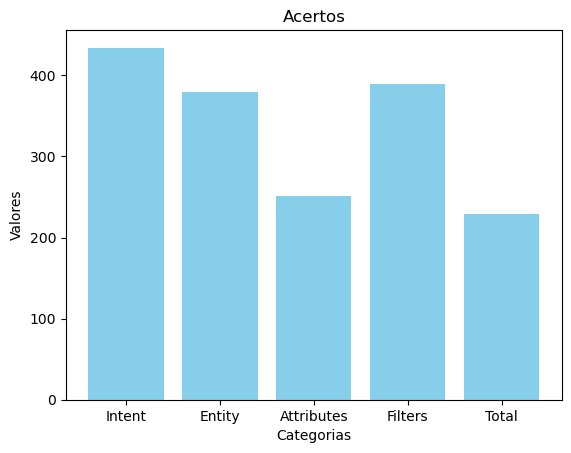

In [101]:
plt.bar(['Intent', 'Entity', 'Attributes', 'Filters', 'Total'], [cor_intent, cor_entity, cor_att, cor_filter, cor_total], color='skyblue')

plt.title('Acertos')
plt.xlabel('Categorias')
plt.ylabel('Valores')

plt.show()

In [102]:
result = objective_analysis.groupby('att_qnt')['correct_answer'].sum().reset_index()
result.columns = ['att_qnt', 'correct_answer']
print(result)

   att_qnt  correct_answer
0        0              63
1        1              93
2        2              69
3        3               1
4        4               2
5        5               1
6        7               0


In [103]:
total_counts = objective_analysis['att_qnt'].value_counts().reset_index()
total_counts.columns = ['att_qnt', 'total_count']

result_percentage = pd.merge(result, total_counts, on='att_qnt')

result_percentage['accuracy_percentage'] = (result_percentage['correct_answer'] / result_percentage['total_count']) * 100

print(result_percentage)

   att_qnt  correct_answer  total_count  accuracy_percentage
0        0              63          109            57.798165
1        1              93          161            57.763975
2        2              69          160            43.125000
3        3               1           17             5.882353
4        4               2            8            25.000000
5        5               1            3            33.333333
6        7               0            1             0.000000


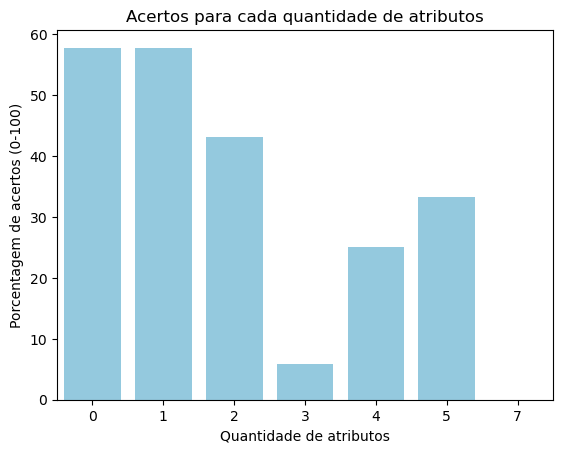

In [104]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=result_percentage, x='att_qnt', y='accuracy_percentage', color='skyblue')

plt.title('Acertos para cada quantidade de atributos')
plt.xlabel('Quantidade de atributos')
plt.ylabel('Porcentagem de acertos (0-100)')

plt.show()

In [105]:
objective_analysis.intent.value_counts()

intent
ADD       169
READ      143
UPDATE     99
DELETE     48
Name: count, dtype: int64

In [106]:
result_intent = objective_analysis.groupby('intent')['correct_answer'].sum().reset_index()
result_intent.columns = ['intent', 'correct_answer']
print(result_intent)

   intent  correct_answer
0     ADD              79
1  DELETE              29
2    READ              82
3  UPDATE              39


In [107]:
total_counts_intent = objective_analysis['intent'].value_counts().reset_index()
total_counts_intent.columns = ['intent', 'total_count']
result_intent_percentage = pd.merge(result_intent, total_counts_intent, on='intent')
result_intent_percentage['accuracy_percentage'] = (result_intent_percentage['correct_answer'] / result_intent_percentage['total_count']) * 100
print(result_intent_percentage)

   intent  correct_answer  total_count  accuracy_percentage
0     ADD              79          169            46.745562
1  DELETE              29           48            60.416667
2    READ              82          143            57.342657
3  UPDATE              39           99            39.393939


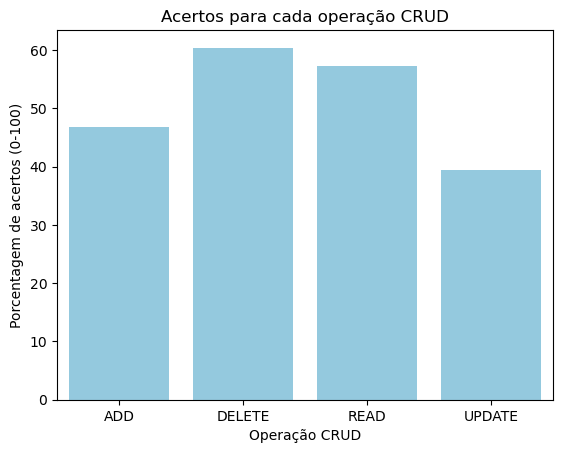

In [108]:
sns.barplot(data=result_intent_percentage, x='intent', y='accuracy_percentage', color='skyblue')

plt.title('Acertos para cada operação CRUD')
plt.xlabel('Operação CRUD')
plt.ylabel('Porcentagem de acertos (0-100)')

plt.show()

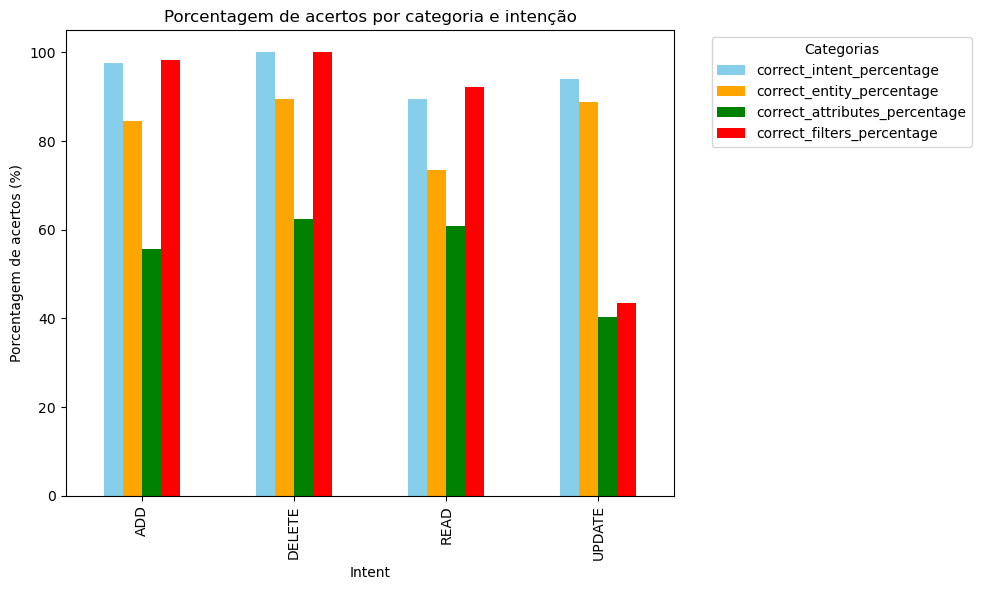

In [123]:
intent_totals = objective_analysis.groupby("intent").size().reset_index(name="total_count")

columns_to_count = ["correct_intent", "correct_entity", "correct_attributes", "correct_filters"]
grouped_data = objective_analysis.groupby("intent")[columns_to_count].sum().reset_index()

grouped_data = pd.merge(grouped_data, intent_totals, on="intent")
for col in columns_to_count:
    grouped_data[f"{col}_percentage"] = (grouped_data[col] / grouped_data["total_count"]) * 100

percentage_columns = [f"{col}_percentage" for col in columns_to_count]
plot_data = grouped_data.set_index("intent")[percentage_columns]

plot_data.plot(kind="bar", figsize=(10, 6), stacked=False, color=["skyblue", "orange", "green", "red"])

plt.title("Porcentagem de acertos por categoria e intenção")
plt.xlabel("Intent")
plt.ylabel("Porcentagem de acertos (%)")
plt.legend(title="Categorias", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

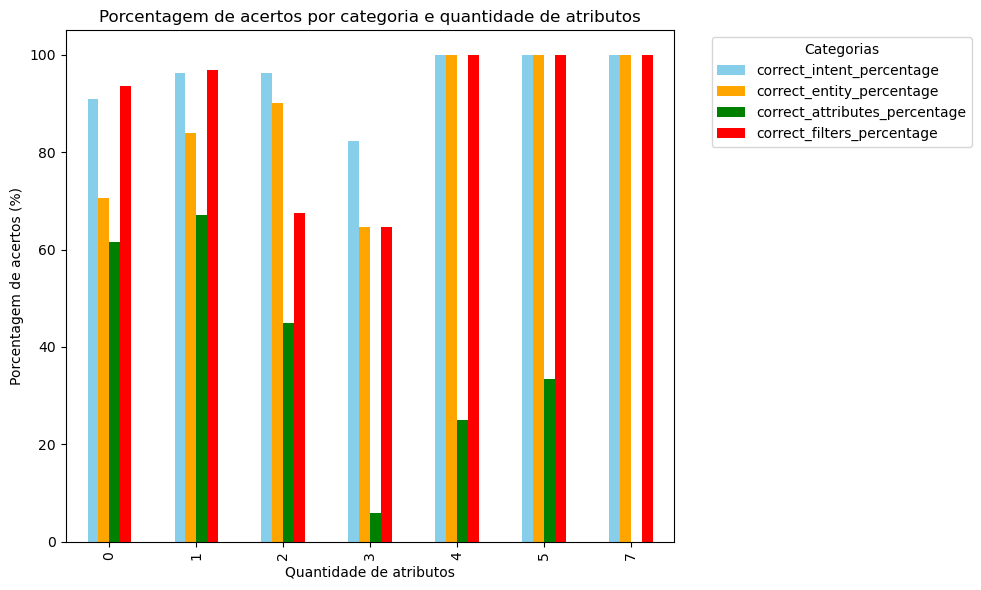

In [125]:
att_totals = objective_analysis.groupby("att_qnt").size().reset_index(name="total_count")

columns_to_count = ["correct_intent", "correct_entity", "correct_attributes", "correct_filters"]
grouped_data = objective_analysis.groupby("att_qnt")[columns_to_count].sum().reset_index()
grouped_data = pd.merge(grouped_data, att_totals, on="att_qnt")
for col in columns_to_count:
    grouped_data[f"{col}_percentage"] = (grouped_data[col] / grouped_data["total_count"]) * 100
percentage_columns = [f"{col}_percentage" for col in columns_to_count]
plot_data = grouped_data.set_index("att_qnt")[percentage_columns]

plot_data.plot(kind="bar", figsize=(10, 6), stacked=False, color=["skyblue", "orange", "green", "red"])

plt.title("Porcentagem de acertos por categoria e quantidade de atributos")
plt.xlabel("Quantidade de atributos")
plt.ylabel("Porcentagem de acertos (%)")
plt.legend(title="Categorias", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()